### Create Gaussian Process around dataset

In [5]:
from sklearn.model_selection import train_test_split

from agent.components import RASK
from agent.components.RASK import get_dependent_variable_mapping
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd

from notebooks.icsoc.globals import DATASET_LOG_SPLITS, \
    PATH_METRICS_ICSOC_EXPLORE, OVERALL_DATASET_USAGE

plt.style.use('default')

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType
from agent.components.commons import SloSet

largest_split = DATASET_LOG_SPLITS[-1]
_df_explore = pd.read_csv(PATH_METRICS_ICSOC_EXPLORE)
_df_total = _df_explore.sample(frac=OVERALL_DATASET_USAGE, random_state=35)
train_df, _test_df_raw = train_test_split(_df_total, test_size=0.20, random_state=35)

test_df = RASK.preprocess_data(_test_df_raw)

services = [ServiceType.QR]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Create Gaussian Processes with certain shares of the exploration data set

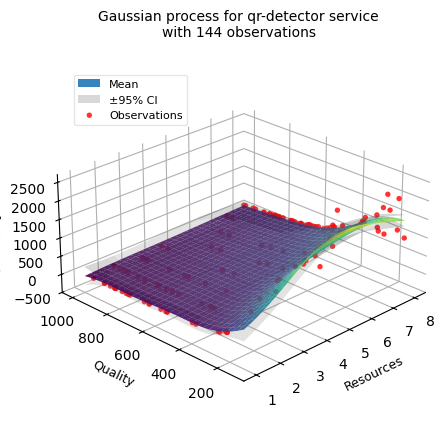

Finished fitting GP with 0.5% data ratio


In [6]:
import plotly.io as pio

pio.renderers.default = 'browser'

lml_history = []

gp_list = []
lml_history = []

for data_ratio in [0.5]:
    gp_all_services = {}
    lml_all_service = []

    for s in services:
        # Initialize and train GP model
        draw_figures = data_ratio in [0.5]
        _gp = GASK(s, create_figures=draw_figures, display_figures=draw_figures)
        _gp.init_model(train_df, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished fitting GP with {data_ratio}% data ratio")




Evaluation for GP trained on 5.0% data
Service QR (82 test samples):
  - Mean Absolute Error (MAE): 212.3057
  - Root Mean Squared Error (RMSE): 282.1879
  - R² Score: 0.2424
  - Empirical Coverage (95% CI): 85.4%


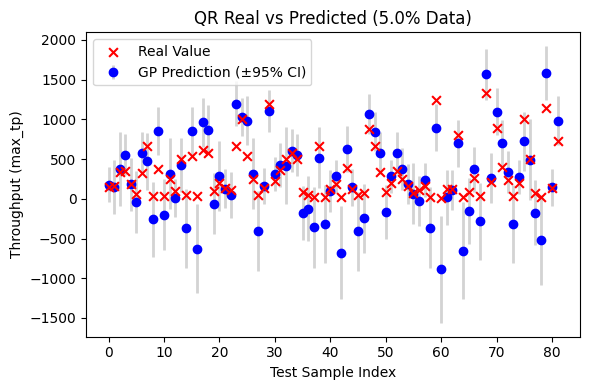

Service CV (68 test samples):
  - Mean Absolute Error (MAE): 2.8518
  - Root Mean Squared Error (RMSE): 5.4774
  - R² Score: 0.2090
  - Empirical Coverage (95% CI): 72.1%


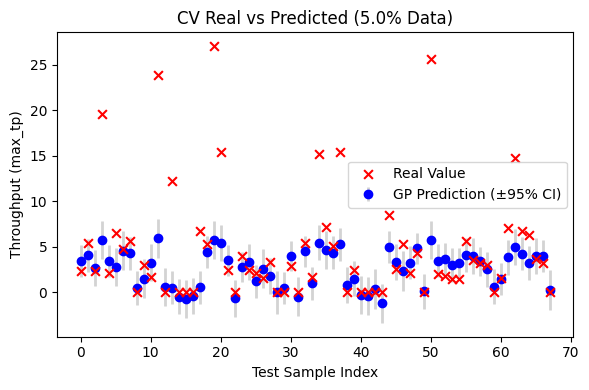

Service PC (66 test samples):
  - Mean Absolute Error (MAE): 28.9180
  - Root Mean Squared Error (RMSE): 49.5094
  - R² Score: 0.7250
  - Empirical Coverage (95% CI): 83.3%


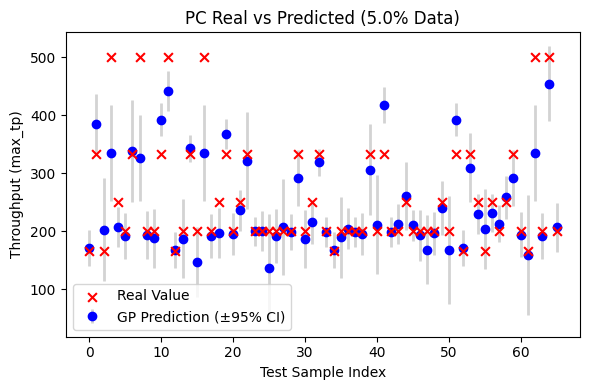


Evaluation for GP trained on 10.0% data
Service QR (82 test samples):
  - Mean Absolute Error (MAE): 93.1475
  - Root Mean Squared Error (RMSE): 164.0979
  - R² Score: 0.7438
  - Empirical Coverage (95% CI): 91.5%


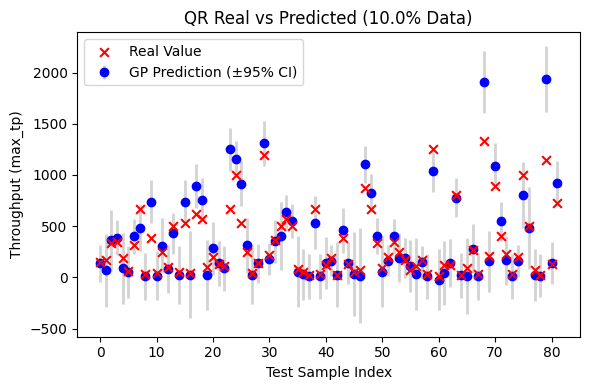

Service CV (68 test samples):
  - Mean Absolute Error (MAE): 1.7761
  - Root Mean Squared Error (RMSE): 3.0536
  - R² Score: 0.7542
  - Empirical Coverage (95% CI): 83.8%


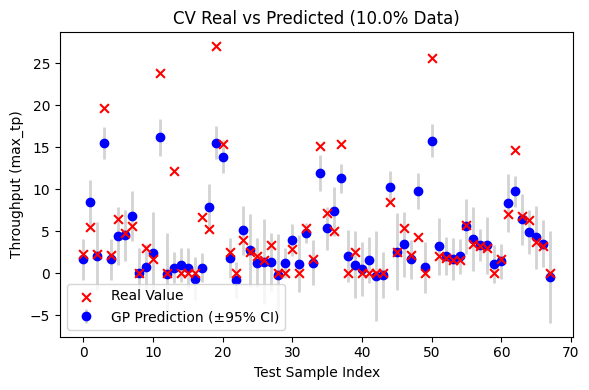

Service PC (66 test samples):
  - Mean Absolute Error (MAE): 22.0974
  - Root Mean Squared Error (RMSE): 39.4551
  - R² Score: 0.8254
  - Empirical Coverage (95% CI): 80.3%


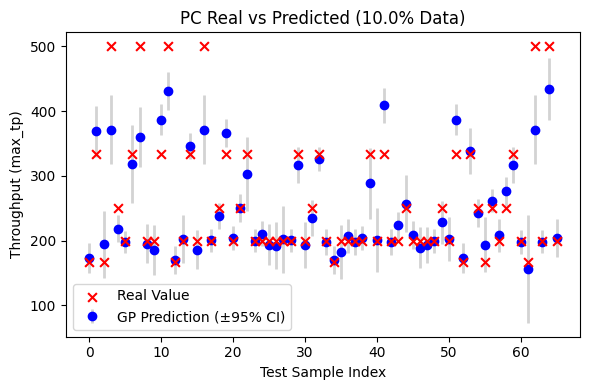


Evaluation for GP trained on 25.0% data
Service QR (82 test samples):
  - Mean Absolute Error (MAE): 55.0483
  - Root Mean Squared Error (RMSE): 113.8172
  - R² Score: 0.8767
  - Empirical Coverage (95% CI): 92.7%


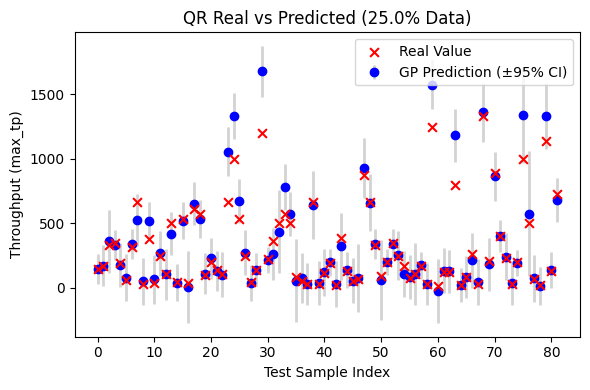

Service CV (68 test samples):
  - Mean Absolute Error (MAE): 2.0666
  - Root Mean Squared Error (RMSE): 3.3460
  - R² Score: 0.7048
  - Empirical Coverage (95% CI): 79.4%


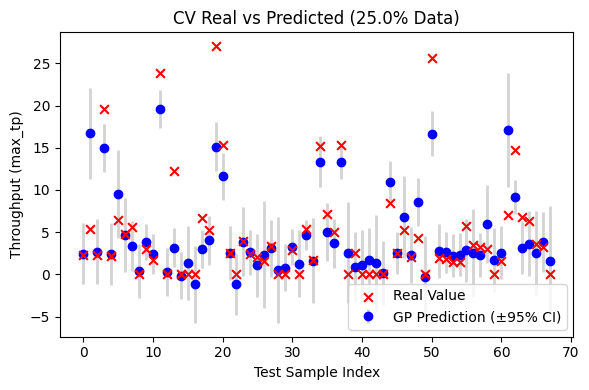

Service PC (66 test samples):
  - Mean Absolute Error (MAE): 21.6600
  - Root Mean Squared Error (RMSE): 38.4389
  - R² Score: 0.8342
  - Empirical Coverage (95% CI): 65.2%


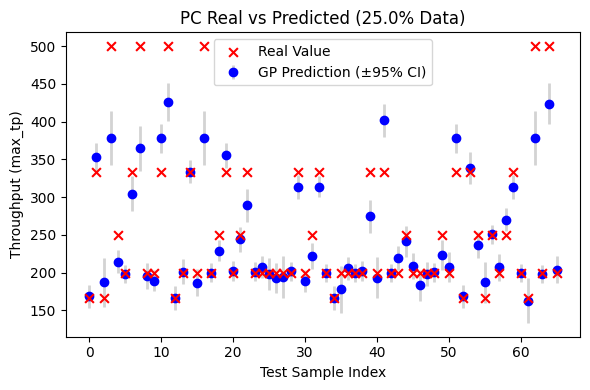


Evaluation for GP trained on 50.0% data
Service QR (82 test samples):
  - Mean Absolute Error (MAE): 46.5877
  - Root Mean Squared Error (RMSE): 93.8023
  - R² Score: 0.9163
  - Empirical Coverage (95% CI): 89.0%


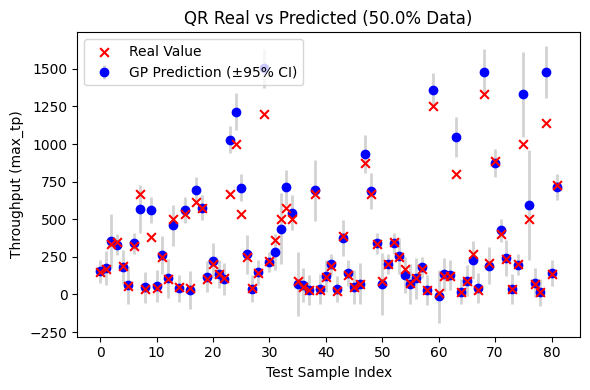

Service CV (68 test samples):
  - Mean Absolute Error (MAE): 1.5418
  - Root Mean Squared Error (RMSE): 2.7640
  - R² Score: 0.7986
  - Empirical Coverage (95% CI): 76.5%


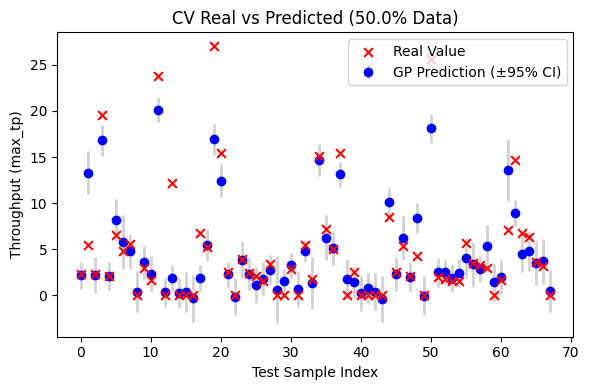

Service PC (66 test samples):
  - Mean Absolute Error (MAE): 18.9001
  - Root Mean Squared Error (RMSE): 34.4442
  - R² Score: 0.8669
  - Empirical Coverage (95% CI): 62.1%


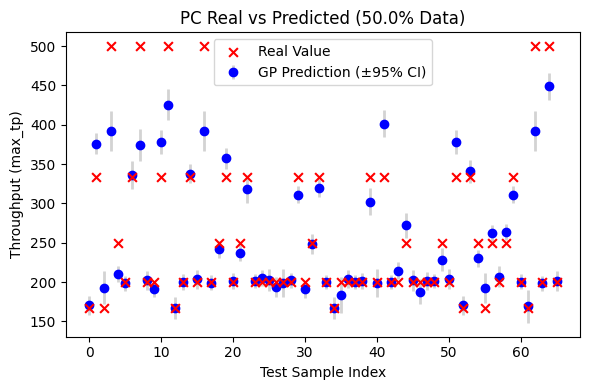


Evaluation for GP trained on 100.0% data
Service QR (82 test samples):
  - Mean Absolute Error (MAE): 52.7971
  - Root Mean Squared Error (RMSE): 125.1794
  - R² Score: 0.8509
  - Empirical Coverage (95% CI): 82.9%


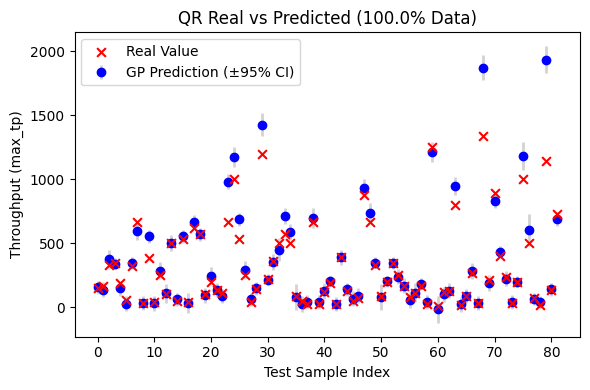

Service CV (68 test samples):
  - Mean Absolute Error (MAE): 1.4510
  - Root Mean Squared Error (RMSE): 2.6102
  - R² Score: 0.8204
  - Empirical Coverage (95% CI): 75.0%


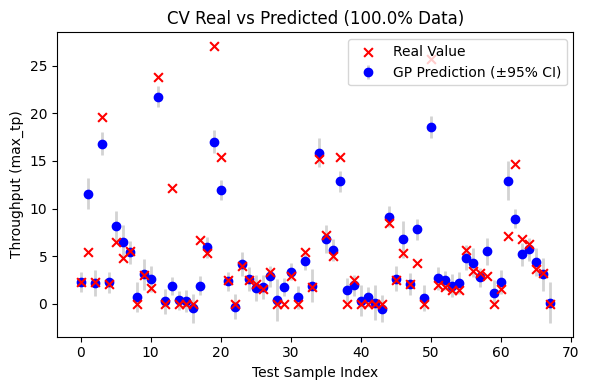

Service PC (66 test samples):
  - Mean Absolute Error (MAE): 16.6036
  - Root Mean Squared Error (RMSE): 26.5162
  - R² Score: 0.9211
  - Empirical Coverage (95% CI): 60.6%


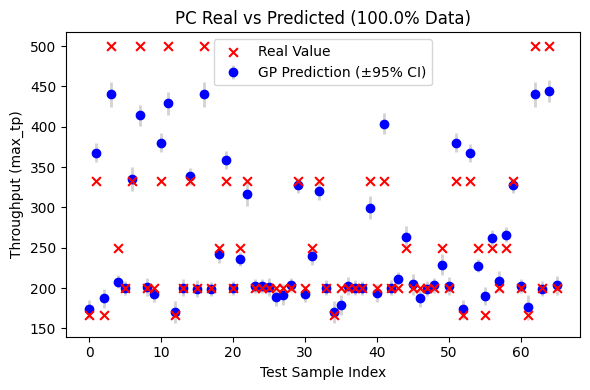

In [9]:
### Evaluate GP Predictions on the Test Split
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from agent.components.commons import ServiceVar

# Dependent variable we want to predict and evaluate
target_var = "max_tp"

# We will evaluate the GPs trained at each data ratio level
for data_ratio_idx, data_ratio in enumerate(DATASET_LOG_SPLITS):
    print(f"\n==========================================")
    print(f"Evaluation for GP trained on {data_ratio * 100:.1f}% data")
    print(f"==========================================")

    # Get the GP models dict for this specific data split ratio
    trained_gps = gp_list[data_ratio_idx]

    for s in services:
        test_df_service = test_df[test_df["service_type"] == s.value]
        # Get the trained GASK instance for this service
        gp_instance = trained_gps[s]

        # 1. Identify which features (independent variables) this service and target depend on
        # This matches the internals of your predict function
        deps = get_dependent_variable_mapping(s)[target_var]
        #
        # # 2. Filter test dataframe to rows that don't contain NaNs in required columns
        # required_cols = list(deps) + [target_var]
        # service_test_df = test_df
        #
        # if service_test_df.empty:
        #     print(f"Service {s.name}: No valid test samples found.")
        #     continue

        actual_values = test_df_service[target_var].values
        predictions = []
        uncertainties = []

        # 3. Predict for each test row
        for _, row in test_df_service.iterrows():
            # Build the sample state dictionary matching ServiceVar keys expected by predict()
            sample_state = {ServiceVar(k): row[k] for k in deps}

            # Call your predict function
            mu, sigma = gp_instance.predict(s, target_var, sample_state)

            predictions.append(mu)
            uncertainties.append(sigma)

        predictions = np.array(predictions)
        uncertainties = np.array(uncertainties)

        # 4. Calculate metrics
        mae = mean_absolute_error(actual_values, predictions)
        rmse = root_mean_squared_error(actual_values, predictions)
        r2 = r2_score(actual_values, predictions)

        # Calculate how many actual values fell within the GP's 95% confidence interval (±1.96 * sigma)
        lower_bound = predictions - 1.96 * uncertainties
        upper_bound = predictions + 1.96 * uncertainties
        inside_ci = np.mean((actual_values >= lower_bound) & (actual_values <= upper_bound)) * 100

        print(f"Service {s.name} ({len(actual_values)} test samples):")
        print(f"  - Mean Absolute Error (MAE): {mae:.4f}")
        print(f"  - Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"  - R² Score: {r2:.4f}")
        print(f"  - Empirical Coverage (95% CI): {inside_ci:.1f}%")

        # 5. Quick optional visualization of Predictions vs. Actuals
        plt.figure(figsize=(6, 4))
        plt.errorbar(
            range(len(actual_values)),
            predictions,
            yerr=1.96 * uncertainties,
            fmt='o',
            color='blue',
            ecolor='lightgray',
            elinewidth=2,
            capsize=0,
            label='GP Prediction (±95% CI)'
        )
        plt.scatter(
            range(len(actual_values)),
            actual_values,
            color='red',
            marker='x',
            s=40,
            zorder=3,
            label='Real Value'
        )
        plt.title(f"{s.name} Real vs Predicted ({data_ratio * 100:.1f}% Data)")
        plt.xlabel("Test Sample Index")
        plt.ylabel("Throughput (max_tp)")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()